# 04 · Payment Behavior Over Time
### Credit Risk Analysis

**Notebook 4 of 6.** Notebook 03 looked at *who* defaults using a static snapshot
of each applicant. This notebook adds the **time dimension**: how repayment
behavior unfolds month by month as an account ages. This is the kind of
behavioral, time-based analysis that separates a strong analyst from someone who
only does cross-tabs — and it speaks directly to the **vintage analysis** idea we
used to engineer the target.

Four questions drive the notebook:

1. **When do accounts go bad?** Does delinquency rise as an account seasons?
2. **What does the status mix look like over time?** How does the split between
   paid / mildly late / seriously delinquent evolve with account age?
3. **How quickly do bad clients go bad?** Among clients who ever hit 60+ DPD, how
   long after opening does it first happen?
4. **Is early behavior an early-warning sign?** Do small slips in the first few
   months predict serious delinquency later?

## 1. Setup, load history, and rebuild the time features

**What:** Load `credit_record.csv`, map `STATUS` to a days-past-due tier, and
compute **months on book** (account age) for every record — the number of months
after a client's first appearance that the record occurred.

**Why:** All four analyses are framed by *account age*, not calendar date, so that
a client who opened long ago and one who opened recently are compared at the same
stage of their lifecycle. Rebuilding the same `dpd` and `months_on_book` features
we defined in notebook 02 keeps this notebook self-contained and consistent with
the target definition.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

credit = pd.read_csv("../data/raw/credit_record.csv")

# Days-past-due tier (C = paid, X = no loan -> not delinquent)
dpd_tier = {"X": 0, "C": 0, "0": 0, "1": 30, "2": 60, "3": 90, "4": 120, "5": 150}
credit["dpd"] = credit["STATUS"].map(dpd_tier)

# Account age = months after the client's first record
first_month = credit.groupby("ID")["MONTHS_BALANCE"].transform("min")
credit["months_on_book"] = credit["MONTHS_BALANCE"] - first_month

print(f"{len(credit):,} client-month records | {credit['ID'].nunique():,} clients")
print(f"Account age spans {credit['months_on_book'].min():.0f}–{credit['months_on_book'].max():.0f} months on book")
credit.head()

1,048,575 client-month records | 45,985 clients
Account age spans 0–60 months on book


,ID,MONTHS_BALANCE,STATUS,dpd,months_on_book
0,5001711,0,X,0,3
1,5001711,-1,0,0,2
2,5001711,-2,0,0,1
3,5001711,-3,0,0,0
4,5001712,0,C,0,18


## 2. Delinquency rate by account age (the vintage curve)

**What:** For each value of months-on-book, compute the share of client-month
records that are **60+ days past due**. Plot it as a curve, and only show ages
that still have a reasonable number of accounts.

**Why:** This is the classic **vintage curve**. If delinquency climbs with
account age, risk "seasons" over time and a fixed performance window is essential
for fair comparison (exactly why we built a 24-month window in notebook 02). The
sample thins at high ages (few accounts are observed that long), so we cap the
curve where the data is still trustworthy.

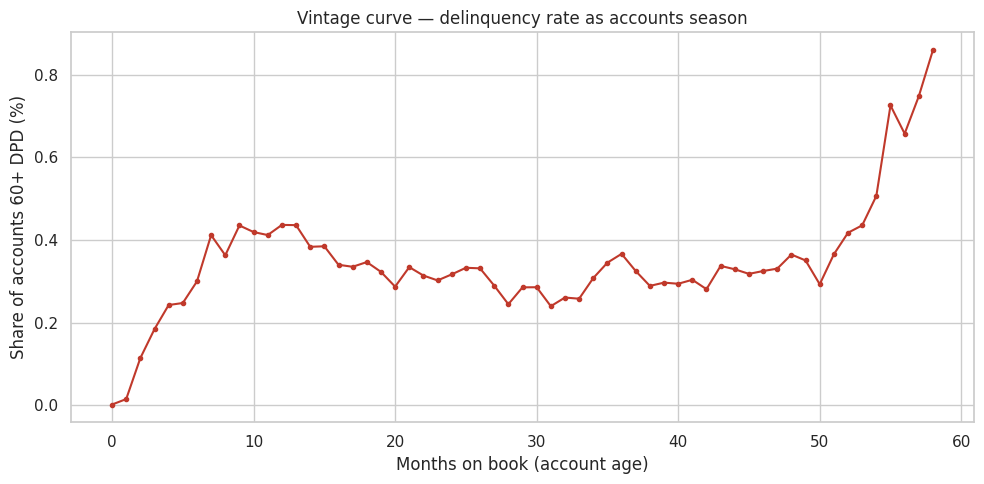

,n_records,delinq_rate_%
months_on_book,,
0,45985,0.00
1,45586,0.02
2,44498,0.11
3,43335,0.18
4,41996,0.24
5,40769,0.25
6,39330,0.30
7,37873,0.41
8,36342,0.36


In [2]:
by_age = credit.groupby("months_on_book").agg(
    n_records=("dpd", "size"),
    bad60=("dpd", lambda s: (s >= 60).sum()),
)
by_age["delinq_rate_%"] = by_age["bad60"] / by_age["n_records"] * 100

# Keep ages with enough accounts to be meaningful
solid = by_age[by_age["n_records"] >= 500]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(solid.index, solid["delinq_rate_%"], marker="o", ms=3, color="#c0392b")
ax.set_xlabel("Months on book (account age)")
ax.set_ylabel("Share of accounts 60+ DPD (%)")
ax.set_title("Vintage curve — delinquency rate as accounts season")
plt.tight_layout()
plt.savefig("../visualizations/04_vintage_curve.png", dpi=120, bbox_inches="tight")
plt.show()
display(solid[["n_records", "delinq_rate_%"]].head(12).round(2))

## 3. How the status mix evolves with account age

**What:** Group the eight raw statuses into four readable buckets — **Paid / no
loan** (`C`,`X`), **1–29 DPD** (`0`), **30–59 DPD** (`1`), and **60+ DPD**
(`2`–`5`) — and plot their share at each account age as a stacked area chart.

**Why:** The single vintage curve shows only the worst bucket. The full
composition reveals the *texture* of behavior over time: whether the healthy
"paid" share erodes, and whether accounts pass through mild lateness before
serious delinquency. That progression is what makes early behavior potentially
predictive (tested in section 5).

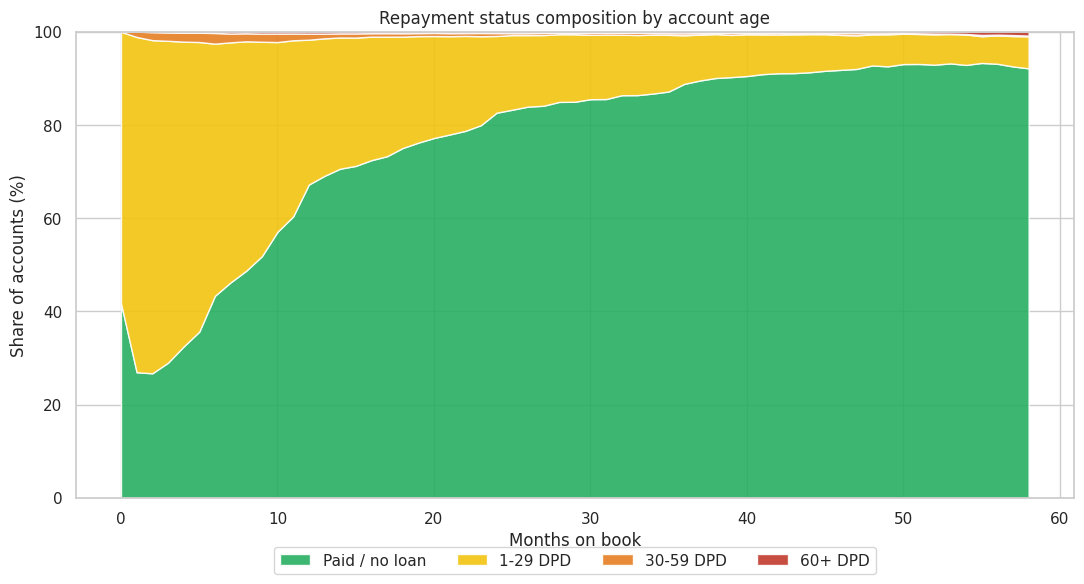

In [3]:
def bucket(dpd):
    if dpd == 0:   return "Paid / no loan"
    if dpd < 30:   return "1-29 DPD"
    if dpd < 60:   return "30-59 DPD"
    return "60+ DPD"

# dpd==0 covers C, X and status '0' (1-29). Separate 'paid/no loan' from '1-29'.
status_group = np.select(
    [credit["STATUS"].isin(["C", "X"]),
     credit["STATUS"] == "0",
     credit["STATUS"] == "1"],
    ["Paid / no loan", "1-29 DPD", "30-59 DPD"],
    default="60+ DPD",
)
credit["status_group"] = status_group

order = ["Paid / no loan", "1-29 DPD", "30-59 DPD", "60+ DPD"]
comp = (credit[credit["months_on_book"].isin(solid.index)]
        .groupby(["months_on_book", "status_group"]).size()
        .unstack(fill_value=0))
comp = comp.div(comp.sum(axis=1), axis=0)[order] * 100

fig, ax = plt.subplots(figsize=(11, 6))
colors = ["#27ae60", "#f1c40f", "#e67e22", "#c0392b"]
ax.stackplot(comp.index, [comp[c] for c in order], labels=order, colors=colors, alpha=0.9)
ax.set_xlabel("Months on book")
ax.set_ylabel("Share of accounts (%)")
ax.set_title("Repayment status composition by account age")
ax.set_ylim(0, 100)
ax.legend(loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.18))
plt.tight_layout()
plt.savefig("../visualizations/04_status_composition.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. How quickly do "bad" clients first go bad?

**What:** Among clients who ever reach 60+ DPD, find the **account age at which it
first happens**, and show both the distribution and the cumulative share.

**Why:** This tells us *when* the risk materializes. If most bad clients first
default early (within the first one or two years), then a relatively short
performance window captures almost all of them — which both justifies the
24-month vintage window from notebook 02 and is useful operationally (you learn
who is risky quickly).

Bad clients (ever 60+ DPD): 667
Median months to first 60+ DPD: 8
Share first defaulting within 12 months: 75.4%
Share first defaulting within 24 months: 91.5%


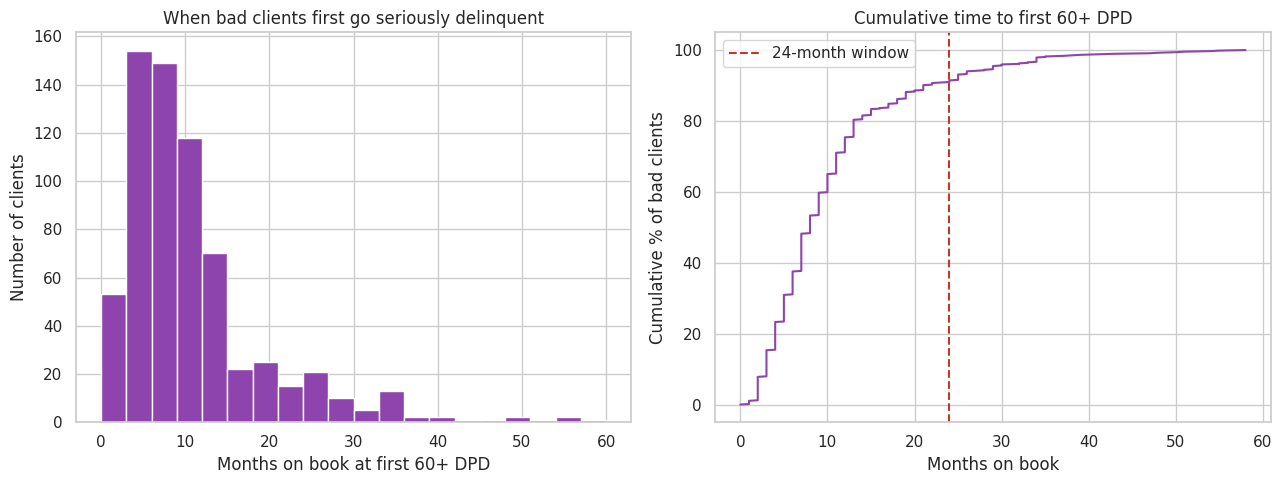

In [4]:
bad_clients = credit.groupby("ID")["dpd"].max()
bad_ids = bad_clients[bad_clients >= 60].index

first_bad = (credit[(credit["ID"].isin(bad_ids)) & (credit["dpd"] >= 60)]
             .groupby("ID")["months_on_book"].min())

print(f"Bad clients (ever 60+ DPD): {len(first_bad):,}")
print(f"Median months to first 60+ DPD: {first_bad.median():.0f}")
print(f"Share first defaulting within 12 months: {(first_bad <= 12).mean()*100:.1f}%")
print(f"Share first defaulting within 24 months: {(first_bad <= 24).mean()*100:.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.hist(first_bad, bins=range(0, int(first_bad.max())+3, 3), color="#8e44ad", edgecolor="white")
ax1.set_xlabel("Months on book at first 60+ DPD")
ax1.set_ylabel("Number of clients")
ax1.set_title("When bad clients first go seriously delinquent")

s = first_bad.sort_values()
cum = np.arange(1, len(s)+1) / len(s) * 100
ax2.plot(s.values, cum, color="#8e44ad")
ax2.axvline(24, color="#c0392b", ls="--", label="24-month window")
ax2.set_xlabel("Months on book")
ax2.set_ylabel("Cumulative % of bad clients")
ax2.set_title("Cumulative time to first 60+ DPD")
ax2.legend()
plt.tight_layout()
plt.savefig("../visualizations/04_time_to_default.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Is early lateness an early-warning sign?

**What:** Split clients by whether they were **ever 30+ DPD in their first 6
months on book**, then compare how often each group later (month 6 onward)
reaches **60+ DPD**. We restrict to clients observed beyond month 6 so both groups
have a real "later" period.

**Why:** This is the most decision-relevant question in the notebook. If clients
who slip early are markedly more likely to default later, then early repayment
behavior carries genuine predictive signal — a finding a lender could act on
(closer monitoring, lower limits) and a natural bridge to the modeling notebook.

Eligible clients (observed past month 6): 39,330

  Clean early period                      n= 36,985  later 60+ DPD = 0.87%
  Slipped early (30+ DPD in first 6m)     n=  2,345  later 60+ DPD = 10.15%

=> Early-slippers are 11.7x more likely to seriously default later.


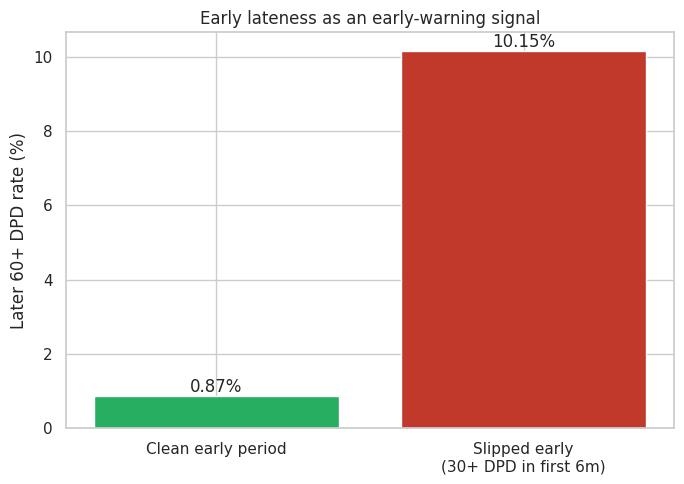

In [5]:
WINDOW = 6
# Clients observed beyond the early window
observed_beyond = credit.groupby("ID")["months_on_book"].max()
eligible = observed_beyond[observed_beyond >= WINDOW].index
sub = credit[credit["ID"].isin(eligible)]

early = sub[sub["months_on_book"] < WINDOW].groupby("ID")["dpd"].max() >= 30   # 30+ early
later = sub[sub["months_on_book"] >= WINDOW].groupby("ID")["dpd"].max() >= 60  # 60+ later

flags = pd.concat([early.rename("early_late"), later.rename("later_bad")], axis=1).dropna()
rates = flags.groupby("early_late")["later_bad"].mean() * 100
counts = flags.groupby("early_late")["later_bad"].size()

print(f"Eligible clients (observed past month {WINDOW}): {len(flags):,}\n")
for k in [False, True]:
    label = "Slipped early (30+ DPD in first 6m)" if k else "Clean early period"
    print(f"  {label:38s}  n={counts[k]:>7,}  later 60+ DPD = {rates[k]:.2f}%")
lift = rates[True] / rates[False] if rates[False] > 0 else np.nan
print(f"\n=> Early-slippers are {lift:.1f}x more likely to seriously default later.")

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(["Clean early period", "Slipped early\n(30+ DPD in first 6m)"],
              [rates[False], rates[True]], color=["#27ae60", "#c0392b"])
for b, v in zip(bars, [rates[False], rates[True]]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{v:.2f}%", ha="center", va="bottom", fontsize=12)
ax.set_ylabel("Later 60+ DPD rate (%)")
ax.set_title("Early lateness as an early-warning signal")
plt.tight_layout()
plt.savefig("../visualizations/04_early_warning.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Key findings

> These extend the project's **Key Findings** with the behavioral, over-time view.
> Figures come from the cells above so the narrative always matches the run.

In [6]:
print(f"Vintage curve: delinquency rate rises from "
      f"{solid['delinq_rate_%'].iloc[0]:.2f}% at opening toward "
      f"{solid['delinq_rate_%'].iloc[-1]:.2f}% at {solid.index[-1]:.0f} months on book.")
print(f"Median time to first 60+ DPD among bad clients: {first_bad.median():.0f} months "
      f"({(first_bad <= 24).mean()*100:.0f}% within 24 months).")
print(f"Early-warning lift: early-slippers default later at {rates[True]:.2f}% "
      f"vs {rates[False]:.2f}% — about {lift:.1f}x higher.")

Vintage curve: delinquency rate rises from 0.00% at opening toward 0.86% at 58 months on book.
Median time to first 60+ DPD among bad clients: 8 months (91% within 24 months).
Early-warning lift: early-slippers default later at 10.15% vs 0.87% — about 11.7x higher.


**Reading the results:**

- **Risk seasons with account age.** The vintage curve shows the 60+ DPD share is
  low at origination and climbs as accounts mature, confirming that *how long an
  account has been open* must be controlled for — the rationale behind the
  performance window used to build the target.
- **The healthy share erodes gradually.** The status-composition chart shows
  accounts mostly sitting in "paid / no loan", with mild (1–29 DPD) lateness
  appearing before serious delinquency — behavior tends to deteriorate in stages
  rather than jump straight to default.
- **Bad clients reveal themselves early.** Most clients who ever hit 60+ DPD do so
  within the first couple of years, so a short performance window captures the
  large majority of eventual defaults — useful both analytically and operationally.
- **Early lateness is a strong early-warning sign.** Clients who slip (30+ DPD) in
  their first six months are several times more likely to seriously default later
  than those with a clean start — an actionable, monitorable signal.
- **Caveat:** these curves thin out at high account ages (fewer accounts observed
  that long), so the right-hand tail of each chart rests on smaller samples and
  should be read as indicative.

➡️ **Next notebook (`05`):** clean and prepare the features, then fit an
interpretable model to quantify *how much* each factor moves the risk — pulling
the static (notebook 03) and behavioral (this notebook) signals together.